In [1]:
import numpy as np 
from netCDF4 import Dataset
import os
import tensorflow as tf
import argparse
import pandas as pd
from tensorflow import keras

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import time
import matplotlib
import matplotlib.ticker as mticker
import warnings


In [2]:
HOME = "/scistor/ivm/the410/"

#HOME = "/home/thappe/" #snellius

In [3]:
os.chdir(f"{HOME}HeaT")
#sys.path.append(os.path.expanduser('/home/thappe/HeaT'))

from HeaT.TFrecord_utils_ERA_v2 import *
from HeaT.reconstruction import *

In [4]:
os.chdir(f"{HOME}/VAE3D/autoencoder_notebooks/LatentSpace/P1/")

from model.autoencoder_3d_model_v1 import CVAE

In [5]:
pwd

'/scistor/ivm/the410/VAE3D/autoencoder_notebooks/LatentSpace/P1'

In [7]:
### GLOBAL VARIABLES IVM

os.chdir(HOME)

#IVM 
data_path = "/scistor/ivm/the410/PAPER3"

#SNELLIUS
# data_path = "/home/thappe/data/MODEL_VAE"

In [8]:
ls /scistor/ivm/the410/PAPER3

ERA5_t2m_dynamic_encoded_heatwaves_L128.csv
ERA5_t2m_dynamic_heatwaves_dates.csv
ERA5_t2m_encoded_heatwaves_L128.csv
ERA5_t2m_heatwaves_dates.csv
ERA5_t2m_minus_thermo_encoded_heatwaves_L128.csv
GMM.pkl
Kmeanseucl.pkl
t2m_data_from_snellius_for_gdbscan/
tf_records/
VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5


## LOADING DATA 

In [9]:
t2m_name = "t2m_minus_thermo" 

assert t2m_name in ["t2m", "t2m_dynamic", "t2m_minus_thermo"], "data not available for this var"

tf_record_file = f"{data_path}/tf_records/TF_record_ERA5_{t2m_name}_1940-2023_standardization_cut.tfrecord"

In [10]:
data = load_tfrecords_ERA5(tf_record_file)

2025-03-19 10:34:23.515761: E tensorflow/stream_executor/cuda/cuda_driver.cc:271] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-03-19 10:34:23.515808: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: node013
2025-03-19 10:34:23.515815: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: node013
2025-03-19 10:34:23.515922: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: 550.54.15
2025-03-19 10:34:23.515938: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: 550.54.15
2025-03-19 10:34:23.515942: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:310] kernel version seems to match DSO: 550.54.15


In [11]:
# #LOAD data from records
# data_train_raw = load_tfrecords(np.arange(101,115,1), norm_method)
# data_val_raw = load_tfrecords(np.arange(115,117,1), norm_method)

#Get a sample to use for visualisation during training
data_testbatch = data.map(parse_function_full_era5).take(1) #selecting only one for visualisation

data_parsed = data.map(parse_function_full_era5)

In [12]:
data_testbatch


for element in data_testbatch.as_numpy_iterator(): #to convert to numpy elements
    array = np.transpose(element[0])
    stream_in = array[0, :, :, :] 
    psl_in = array[1, :, :, :]
    date = str(element[1]) + "_" + str(element[2]) + "_" + str(element[3]) 

## reconstruction and plottin

In [57]:
pwd

'/scistor/ivm/the410'

In [13]:
VAE_model = (128, f"{data_path}/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5")

In [14]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

/scistor/ivm/the410/PAPER3/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5


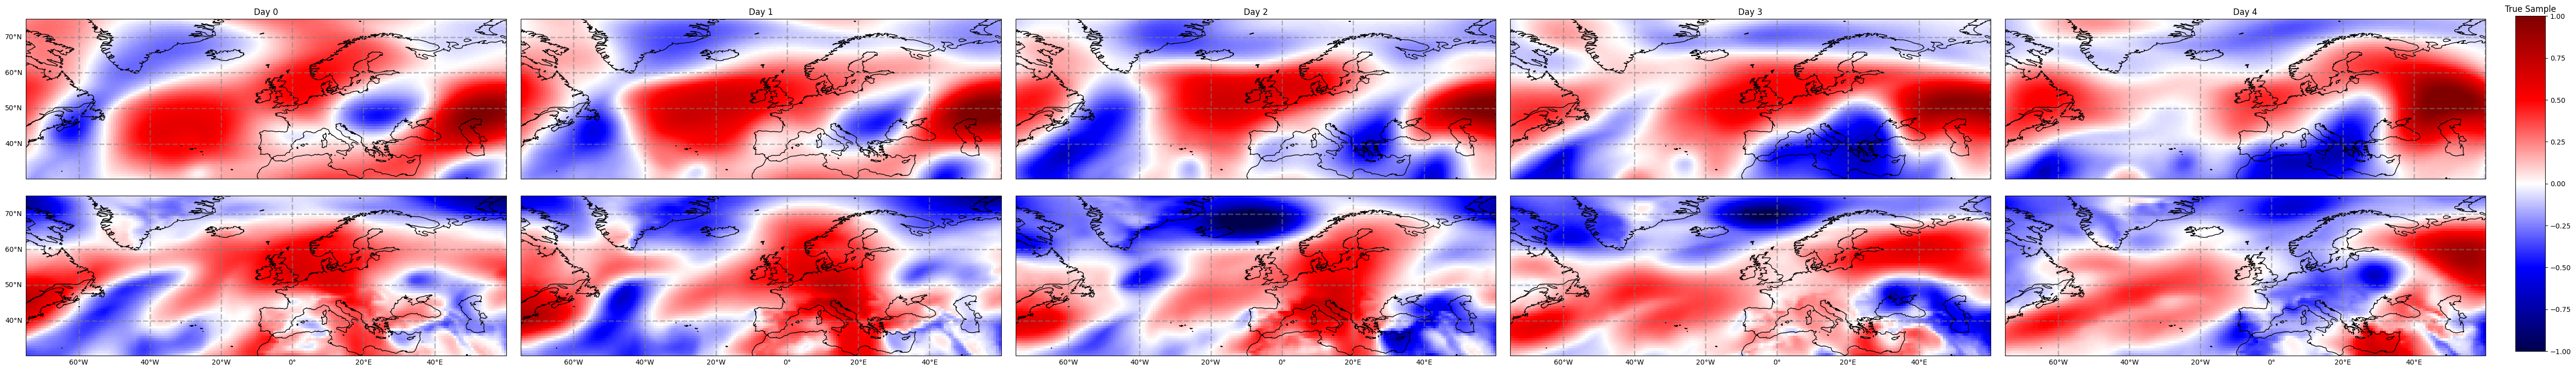

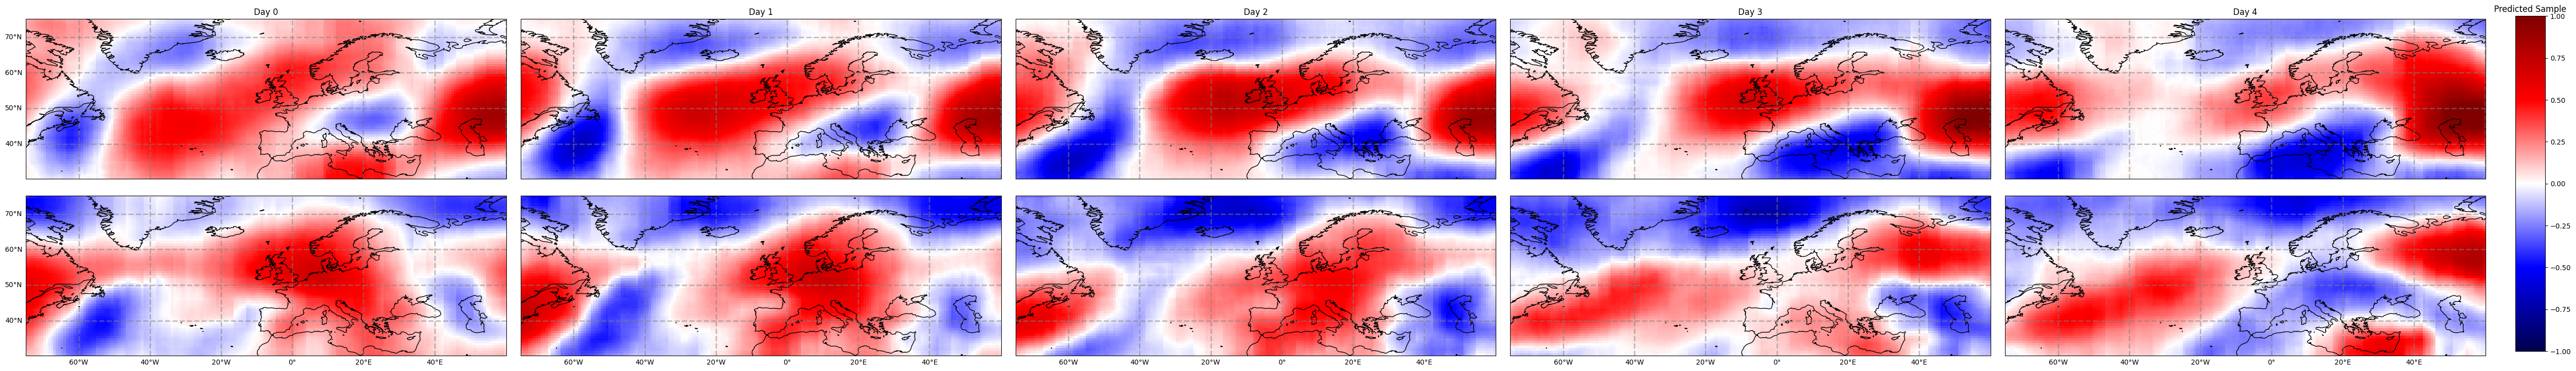

In [15]:
print(VAE_model[1])

reconstruct_VAE_ERA5(VAE_model[1], VAE_model[0], data_testbatch)

In [16]:
print(VAE_model[1])

r2_era5 = get_r2_reconstructed_ERA5(VAE_model[1], VAE_model[0], data_parsed)


/scistor/ivm/the410/PAPER3/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5


In [17]:
len(r2_era5)

739

In [18]:
np.mean(r2_era5)


0.8890415122210358

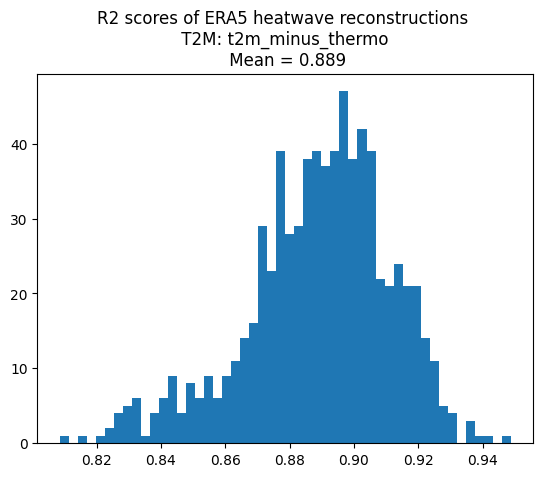

In [19]:

plt.hist(r2_era5, bins=50)
plt.title(f"R2 scores of ERA5 heatwave reconstructions \n T2M: {t2m_name} \n Mean = {round(np.mean(r2_era5), 3)}")
plt.show()

# encoding heatwaves and dates and saving to csv 



In [20]:
heatwave_means = get_heatwave_means(VAE_model[1], VAE_model[0], data_parsed)

In [21]:
## save the means to csv

o = np.ones((VAE_model[0])) #shape of dimensions
nested_lists = [o]
for i in range(len(heatwave_means)):
    nested_lists.append(list(heatwave_means[i]))

import csv
with open(f'{data_path}/ERA5_{t2m_name}_encoded_heatwaves_L{VAE_model[0]}.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(nested_lists)  

In [22]:
#save dates to csv

from datetime import date
dates = []
dates_iso = []
for element in data_parsed.as_numpy_iterator(): #to convert to numpy elements
    array = np.transpose(element[0])
    stream_in = array[0, :, :, :] 
    psl_in = array[1, :, :, :]
    iso_date = date(element[1], element[2], element[3]).isoformat() #year, month, date 
    dates_iso.append([iso_date])
    date_date = date.fromisoformat(iso_date) #to datetime object 
    dates.append(date_date)

In [23]:
with open(f'{data_path}/ERA5_{t2m_name}_heatwaves_dates.csv', 'w', newline='') as f:
    writer = csv.writer(f, delimiter="-")
    writer.writerows(dates_iso) 